In [2]:
!pip install wandb huggingface_hub -q

In [3]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ayanmdkhan2340 (ayanmdkhan2340-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import wandb
from torch.utils.data import DataLoader, random_split
from huggingface_hub import HfApi, create_repo

HF_REPO = "ayan019/exp8-ae-vae"

WANDB_PROJECT = "exp8-ae-vae"
EPOCHS       = 5
BATCH_SIZE   = 128
LATENT_DIMS  = [2, 8, 16, 32]
OPTIMIZERS   = ["adam", "sgd", "rmsprop"]
LOSS_FNS     = ["bce", "mse"]
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.5MB/s]

train: 48000  val: 12000  test: 10000


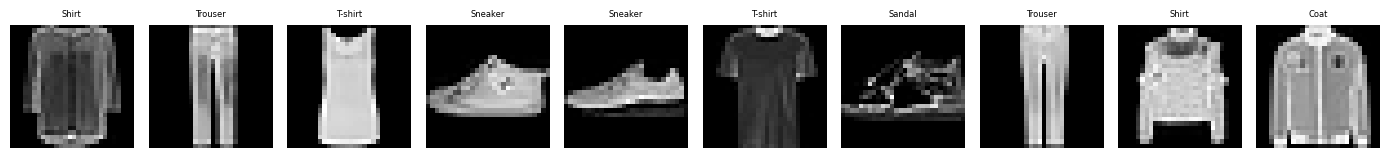

In [6]:
transform = transforms.Compose([
    transforms.ToTensor()
])

full_train = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

n_train = int(0.8 * len(full_train))
n_val   = len(full_train) - n_train

train_set, val_set = random_split(full_train, [n_train, n_val], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_set)}  val: {len(val_set)}  test: {len(test_data)}')

class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i in range(10):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Part A - Autoencoder

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z).view(-1, 1, 28, 28)
        return out, z

### Part B - Variational Autoencoder

In [8]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z

In [9]:
def recon_loss(recon, x, loss_type):
    if loss_type == 'bce':
        return nn.BCELoss()(recon, x)
    return nn.MSELoss()(recon, x)

def vae_loss(recon, x, mu, logvar, loss_type):
    r_loss = recon_loss(recon, x, loss_type)
    kl     = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return r_loss + kl, r_loss, kl

def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=1e-3)
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=1e-3)

In [10]:
def train_ae(model, loader, optimizer, loss_type):
    model.train()
    running = 0
    for x, _ in loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        out, _ = model(x)
        loss = recon_loss(out, x, loss_type)
        loss.backward()
        optimizer.step()
        running += loss.item()
    return running / len(loader)

def evaluate_ae(model, loader, loss_type):
    model.eval()
    running = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            out, _ = model(x)
            running += recon_loss(out, x, loss_type).item()
    return running / len(loader)

def train_vae(model, loader, optimizer, loss_type):
    model.train()
    t_loss = t_recon = t_kl = 0
    for x, _ in loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        out, mu, logvar, _ = model(x)
        loss, rl, kl = vae_loss(out, x, mu, logvar, loss_type)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
        t_recon += rl.item()
        t_kl += kl.item()
    n = len(loader)
    return t_loss/n, t_recon/n, t_kl/n

def evaluate_vae(model, loader, loss_type):
    model.eval()
    t_loss = t_recon = t_kl = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            out, mu, logvar, _ = model(x)
            loss, rl, kl = vae_loss(out, x, mu, logvar, loss_type)
            t_loss += loss.item()
            t_recon += rl.item()
            t_kl += kl.item()
    n = len(loader)
    return t_loss/n, t_recon/n, t_kl/n

In [11]:
def show_reconstructions(model, loader, model_type, title, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(DEVICE)
    with torch.no_grad():
        out = model(x)[0]
    fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().squeeze(), cmap='gray')
        axes[1, i].imshow(out[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Input', fontsize=8)
    axes[1, 0].set_ylabel('Recon', fontsize=8)
    plt.suptitle(title, fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

def show_latent_2d(model, loader, model_type, title):
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            z = model(x)[1] if model_type == 'AE' else model.encode(x)[0]
            zs.append(z.cpu().numpy())
            ys.append(y.numpy())
    zs = np.concatenate(zs)
    ys = np.concatenate(ys)
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(zs[:, 0], zs[:, 1], c=ys, cmap='tab10', s=2, alpha=0.5)
    cb = plt.colorbar(sc, ax=ax)
    cb.set_ticks(range(10))
    cb.set_ticklabels(class_names)
    ax.set_title(title)
    ax.set_xlabel('z0')
    ax.set_ylabel('z1')
    plt.tight_layout()
    plt.show()
    return fig

def show_interpolation(model, loader, model_type, title, steps=10):
    model.eval()
    x, _ = next(iter(loader))
    x1 = x[0:1].to(DEVICE)
    x2 = x[1:2].to(DEVICE)
    with torch.no_grad():
        z1 = model(x1)[1] if model_type == 'AE' else model.encode(x1)[0]
        z2 = model(x2)[1] if model_type == 'AE' else model.encode(x2)[0]
    fig, axes = plt.subplots(1, steps, figsize=(steps * 1.3, 1.8))
    for i, a in enumerate(np.linspace(0, 1, steps)):
        z = (1 - a) * z1 + a * z2
        with torch.no_grad():
            img = model.decoder(z).view(28, 28) if model_type == 'AE' else model.decode(z).squeeze()
        axes[i].imshow(img.cpu(), cmap='gray')
        axes[i].set_title(f'{a:.1f}', fontsize=6)
        axes[i].axis('off')
    plt.suptitle(title, fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

def show_generated(model, title, n=10):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, model.latent_dim).to(DEVICE)
        imgs = model.decode(z)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.3, 1.8))
    for i in range(n):
        axes[i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
        axes[i].axis('off')
    plt.suptitle(title, fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

In [12]:
results = {}
trained_models = {}

def run_experiment(model_type, latent_dim, opt_name, loss_type):
    name = f'{model_type}_ld{latent_dim}_{opt_name}_{loss_type}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'model': model_type,
        'latent_dim': latent_dim,
        'optimizer': opt_name,
        'loss': loss_type,
        'epochs': EPOCHS
    })

    model     = (Autoencoder(latent_dim) if model_type == 'AE' else VAE(latent_dim)).to(DEVICE)
    optimizer = get_optimizer(model, opt_name)

    for epoch in range(1, EPOCHS + 1):
        if model_type == 'AE':
            tr = train_ae(model, train_loader, optimizer, loss_type)
            vl = evaluate_ae(model, val_loader, loss_type)
            wandb.log({'epoch': epoch, 'train_loss': tr, 'val_loss': vl})
            print(f'  epoch {epoch}/{EPOCHS}  train={tr:.4f}  val={vl:.4f}')
        else:
            tr, tr_r, tr_k = train_vae(model, train_loader, optimizer, loss_type)
            vl, vl_r, vl_k = evaluate_vae(model, val_loader, loss_type)
            wandb.log({
                'epoch': epoch,
                'train_loss': tr, 'train_recon': tr_r, 'train_kl': tr_k,
                'val_loss':   vl, 'val_recon':   vl_r, 'val_kl':   vl_k
            })
            print(f'  epoch {epoch}/{EPOCHS}  train={tr:.4f}  recon={tr_r:.4f}  kl={tr_k:.4f}  val={vl:.4f}')

    if model_type == 'AE':
        test_loss = evaluate_ae(model, test_loader, loss_type)
    else:
        test_loss, _, _ = evaluate_vae(model, test_loader, loss_type)

    print(f'  test_loss={test_loss:.4f}')
    wandb.log({'test_loss': test_loss})

    fig = show_reconstructions(model, test_loader, model_type, name)
    wandb.log({'reconstructions': wandb.Image(fig)})
    plt.close(fig)

    fig = show_interpolation(model, test_loader, model_type, f'interpolation - {name}')
    wandb.log({'interpolation': wandb.Image(fig)})
    plt.close(fig)

    if latent_dim == 2:
        fig = show_latent_2d(model, test_loader, model_type, f'latent 2D - {name}')
        wandb.log({'latent_2d': wandb.Image(fig)})
        plt.close(fig)

    if model_type == 'VAE':
        fig = show_generated(model, f'generated - {name}')
        wandb.log({'generated': wandb.Image(fig)})
        plt.close(fig)

    torch.save(model.state_dict(), f'{name}.pt')
    trained_models[name] = model
    results[name] = test_loss

    wandb.finish()
    return model

### Quick Test - run this first

In [13]:
run_experiment('AE',  latent_dim=16, opt_name='adam', loss_type='bce')
run_experiment('VAE', latent_dim=16, opt_name='adam', loss_type='bce')


starting: AE_ld16_adam_bce


  epoch 1/5  train=0.3472  val=0.3055


KeyboardInterrupt: 

### Full Grid - all 48 combinations

In [14]:
for model_type in ['AE', 'VAE']:
    for ld in LATENT_DIMS:
        for opt in OPTIMIZERS:
            for lf in LOSS_FNS:
                run_experiment(model_type, ld, opt, lf)


starting: AE_ld2_adam_bce


epoch,▁
train_loss,▁
val_loss,▁
epoch,1
train_loss,0.34723
val_loss,0.30547


KeyboardInterrupt: 

### Results Summary

In [ ]:
print(f'{"config":<45} {"test_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]):
    print(f'{k:<45} {v:>10.4f}')

best = min(results, key=results.get)
print(f'\nbest: {best}  loss={results[best]:.4f}')

config                                         test_loss
---------------------------------------------------------
AE_ld16_adam_mse                                  0.0134
AE_ld32_adam_mse                                  0.0134
AE_ld8_adam_mse                                   0.0148
AE_ld16_rmsprop_mse                               0.0179
AE_ld8_rmsprop_mse                                0.0180
AE_ld32_rmsprop_mse                               0.0198
AE_ld2_adam_mse                                   0.0279
AE_ld2_rmsprop_mse                                0.0285
VAE_ld32_adam_mse                                 0.0848
VAE_ld32_rmsprop_mse                              0.0855
VAE_ld2_rmsprop_mse                               0.0867
VAE_ld8_adam_mse                                  0.0867
VAE_ld16_rmsprop_mse                              0.0867
VAE_ld2_adam_mse                                  0.0868
VAE_ld8_rmsprop_mse                               0.0869
VAE_ld16_adam_mse             

### Upload to HuggingFace

In [ ]:
import os

create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in trained_models.keys():
    pt_file = f'{name}.pt'
    if os.path.exists(pt_file):
        api.upload_file(
            path_or_fileobj=pt_file,
            path_in_repo=f'models/{pt_file}',
            repo_id=HF_REPO
        )
        print(f'uploaded: {pt_file}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  AE_ld16_adam_bce.pt         :  13%|#2        |  557kB / 4.31MB            

uploaded: AE_ld16_adam_bce.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

uploaded: VAE_ld32_rmsprop_bce.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  VAE_ld32_rmsprop_mse.pt     :  89%|########9 | 3.91MB / 4.37MB            

uploaded: VAE_ld32_rmsprop_mse.pt
https://huggingface.co/nitin032/exp8-ae-vae


In [ ]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/nitinkumarmalviya_25afi24-delhi-technological-university/exp8-ae-vae
HF  : https://huggingface.co/nitin032/exp8-ae-vae
